# Fig 1

In [1]:
import pandas as pd

In [2]:
# Save the DataFrames to CSV
df_france=pd.read_csv("data/df_france_final.csv")
df_chile=pd.read_csv("data/df_chile_final.csv")
df_brazil=pd.read_csv("data/df_brazil_final.csv")

In [3]:
# List of categorical columns to explore
categorical_cols = ["region_type", "Age Range", "political_orientation", "sex"]

# Dictionary mapping dataset names to their respective DataFrames
dataframes = {
    "France": df_france,
    "Chile": df_chile,
    "Brazil": df_brazil
}

for country_name, df in dataframes.items():
    print(f"{'='*50}")
    print(f"DESCRIPTIVE ANALYSIS FOR {country_name.upper()}")
    print(f"{'='*50}\n")

    # 1. Frequency counts for each categorical column
    for col in categorical_cols:
        print(f"Frequency counts for '{col}' in {country_name}:")
        print(df[col].value_counts(dropna=False))
        print("-" * 40)
    
    # 2. Quick descriptive overview (categorical columns only)
    print(f"Descriptive overview (categorical columns) for {country_name}:")
    print(df[categorical_cols].describe(include='object'))
    
    # 3. Cross-tabulations
    print(f"\nCross-tab: region_type by sex for {country_name}")
    print(pd.crosstab(df["region_type"], df["sex"]))
    
    print(f"\nCross-tab: Age Range by political_orientation for {country_name}")
    print(pd.crosstab(df["Age Range"], df["political_orientation"]))

    print("\n\n")  # Blank lines to separate outputs


DESCRIPTIVE ANALYSIS FOR FRANCE

Frequency counts for 'region_type' in France:
region_type
Region      876
Capital     238
Excluded    108
Unknown       6
Name: count, dtype: int64
----------------------------------------
Frequency counts for 'Age Range' in France:
Age Range
20-29 years    509
30-39 years    345
40-49 years    178
50-59 years    101
10-19 years     45
60-69 years     30
Skip            11
70+ years        8
Other            1
Name: count, dtype: int64
----------------------------------------
Frequency counts for 'political_orientation' in France:
political_orientation
Liberal         719
Excluded        215
Conservative    164
Neutral         130
Name: count, dtype: int64
----------------------------------------
Frequency counts for 'sex' in France:
sex
Male        886
Female      288
Excluded     54
Name: count, dtype: int64
----------------------------------------
Descriptive overview (categorical columns) for France:
       region_type    Age Range political_orienta

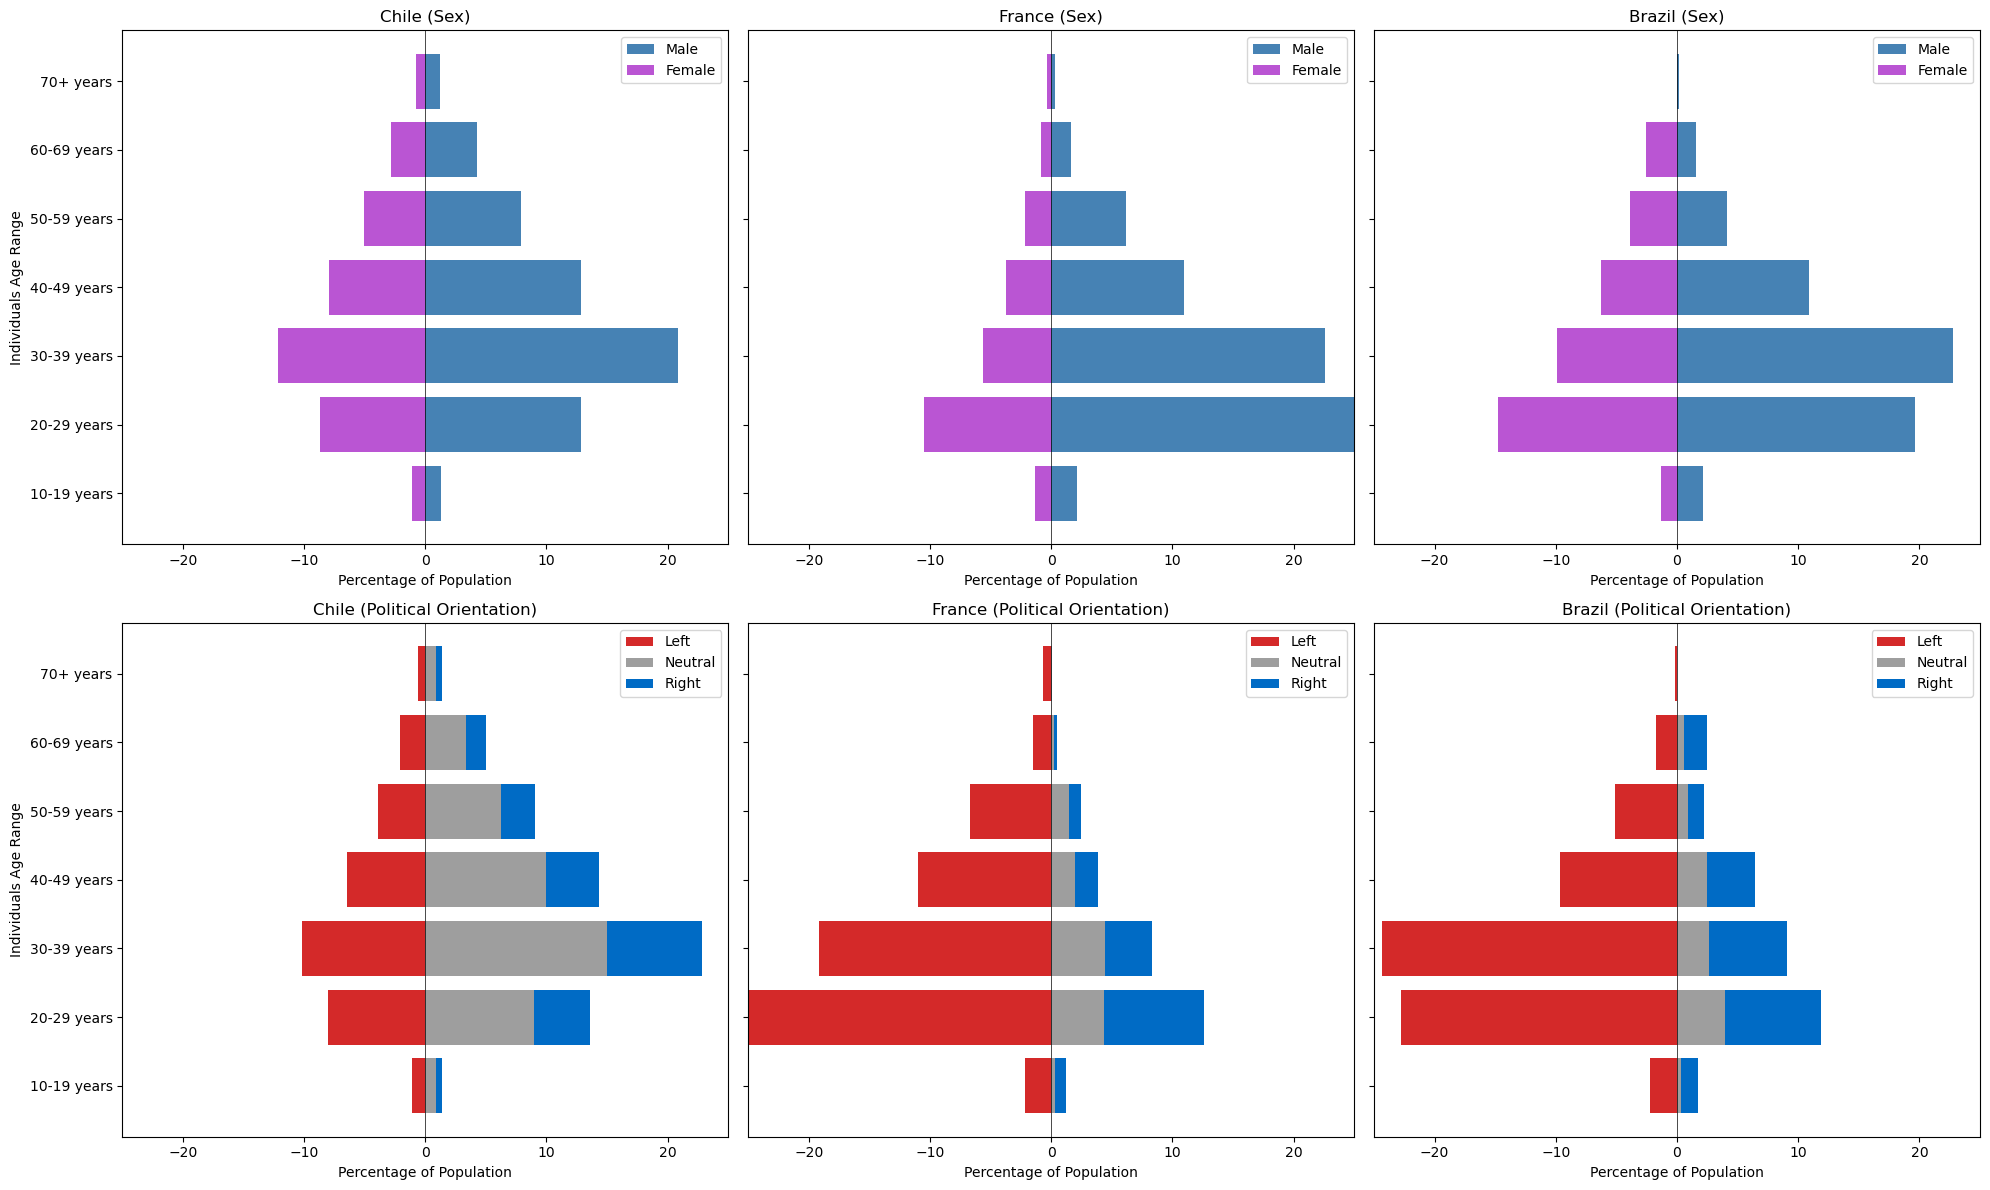

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Re-prepare the sex-based pyramid data
def prepare_population_pyramid(df, age_exclude):
    df_filtered = df[
        (df["sex"].isin(["Male", "Female"])) &
        (~df["Age Range"].isin(age_exclude))
    ].copy()

    grouped = df_filtered.groupby(["Age Range", "sex"]).size().unstack(fill_value=0)
    total_individuals = grouped.sum().sum()
    grouped_percent = grouped / total_individuals * 100
    grouped_percent["Female"] *= -1

    age_order = [
        "10-19 years", "20-29 years", "30-39 years", "40-49 years",
        "50-59 years", "60-69 years", "70+ years"
    ]
    grouped_percent = grouped_percent.reindex(age_order)
    return grouped_percent

# Re-prepare the political orientation data
def prepare_political_orientation(df, age_exclude, orientation_exclude):
    df_filtered = df[
        (~df["Age Range"].isin(age_exclude)) &
        (~df["political_orientation"].isin(orientation_exclude))
    ].copy()

    grouped = df_filtered.groupby(["Age Range", "political_orientation"]).size().unstack(fill_value=0)
    total_individuals = grouped.sum().sum()
    grouped_percent = grouped / total_individuals * 100
    grouped_percent = grouped_percent.reindex([
        "10-19 years", "20-29 years", "30-39 years", "40-49 years",
        "50-59 years", "60-69 years", "70+ years"
    ])
    return grouped_percent

# Prepare datasets
grouped_chile_sex = prepare_population_pyramid(df_chile, ["Under 10"])
grouped_france_sex = prepare_population_pyramid(df_france, ["Other", "Skip"])
grouped_brazil_sex = prepare_population_pyramid(df_brazil, ["Other", "Skip"])

grouped_chile_pol = prepare_political_orientation(df_chile, ["Under 10"], ["Excluded"])
grouped_france_pol = prepare_political_orientation(df_france, ["Other", "Skip"], ["Excluded"])
grouped_brazil_pol = prepare_political_orientation(df_brazil, ["Other", "Skip"], ["Excluded"])

# Colors
sex_colors = {"Male": "#4682B4", "Female": "#BA55D3"}
pol_colors = {
    "Liberal": "#D42929",
    "Neutral": "#9E9E9E",
    "Conservative": "#006BC5"
}

# Create 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True)

# First row: sex-based pyramids
sex_datasets = {
    "Chile": grouped_chile_sex,
    "France": grouped_france_sex,
    "Brazil": grouped_brazil_sex
}
for ax, (country, data) in zip(axes[0], sex_datasets.items()):
    ax.barh(data.index, data["Male"], color=sex_colors["Male"], label="Male")
    ax.barh(data.index, data["Female"], color=sex_colors["Female"], label="Female")
    ax.set_title(f"{country} (Sex)")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlim([-25, 25])
    ax.set_xlabel("Percentage of Population")
    if ax == axes[0, 0]:
        ax.set_ylabel("Individuals Age Range")
    ax.legend()

# Second row: political orientation pyramids
pol_datasets = {
    "Chile": grouped_chile_pol,
    "France": grouped_france_pol,
    "Brazil": grouped_brazil_pol
}
for ax, (country, data) in zip(axes[1], pol_datasets.items()):
    for col in ["Liberal", "Neutral", "Conservative"]:
        if col not in data.columns:
            data[col] = 0
    liberal_vals = -data["Liberal"].abs()
    neutral_vals = data["Neutral"].abs()
    conservative_vals = data["Conservative"].abs()
    neutral_left = np.zeros(len(data))
    conservative_left = neutral_vals
    
    ax.barh(data.index, liberal_vals, color=pol_colors["Liberal"], label="Left")
    ax.barh(data.index, neutral_vals, left=neutral_left, color=pol_colors["Neutral"], label="Neutral")
    ax.barh(data.index, conservative_vals, left=conservative_left, color=pol_colors["Conservative"], label="Right")
    ax.set_title(f"{country} (Political Orientation)")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlim([-25, 25])
    ax.set_xlabel("Percentage of Population")
    if ax == axes[1, 0]:
        ax.set_ylabel("Individuals Age Range")
    ax.legend()

plt.tight_layout()
plt.savefig("Output/Fig 1.svg", format='svg', bbox_inches='tight')
plt.show()

In [5]:
# Helper list for the 20–59 age bands
age_20_59 = ["20-29 years", "30-39 years", "40-49 years", "50-59 years"]

# --- 1) % of participants between 20 and 59 across the three samples ---

combined = pd.concat(
    [
        df_chile.assign(country="Chile"),
        df_france.assign(country="France"),
        df_brazil.assign(country="Brazil"),
    ],
    ignore_index=True,
)

mask_20_59 = combined["Age Range"].isin(age_20_59)
pct_20_59_all = mask_20_59.mean() * 100
print(f"Participants 20–59 across all samples: {pct_20_59_all:.1f}%")

# --- 2) % of men in each country + range YY–ZZ ---

men_pcts = {}

for name, df in dataframes.items():
    valid_sex = df["sex"].isin(["Male", "Female"])
    pct_men = (df.loc[valid_sex, "sex"] == "Male").mean() * 100
    men_pcts[name] = pct_men
    print(f"{name}: men = {pct_men:.1f}% of respondents (valid sex)")

yy = min(men_pcts.values())
zz = max(men_pcts.values())
print(f"Men range across countries: {yy:.1f}–{zz:.1f}%")

# --- 3) % of left-identifying citizens in each country (AA, BB, CC) ---

left_pcts = {}

for name, df in dataframes.items():
    valid_pol = df["political_orientation"].notna() & (df["political_orientation"] != "Excluded")
    
    # Adjust this line depending on how you named the left category:
    #   - if your column has "Liberal" use that
    #   - if it has "Left", change to == "Left"
    left_mask = df.loc[valid_pol, "political_orientation"].isin(["Liberal", "Left"])
    
    pct_left = left_mask.mean() * 100
    left_pcts[name] = pct_left
    print(f"{name}: left-identifying = {pct_left:.1f}% of respondents with valid ideology")


Participants 20–59 across all samples: 88.3%
France: men = 75.5% of respondents (valid sex)
Chile: men = 61.3% of respondents (valid sex)
Brazil: men = 61.3% of respondents (valid sex)
Men range across countries: 61.3–75.5%
France: left-identifying = 71.0% of respondents with valid ideology
Chile: left-identifying = 32.4% of respondents with valid ideology
Brazil: left-identifying = 66.1% of respondents with valid ideology


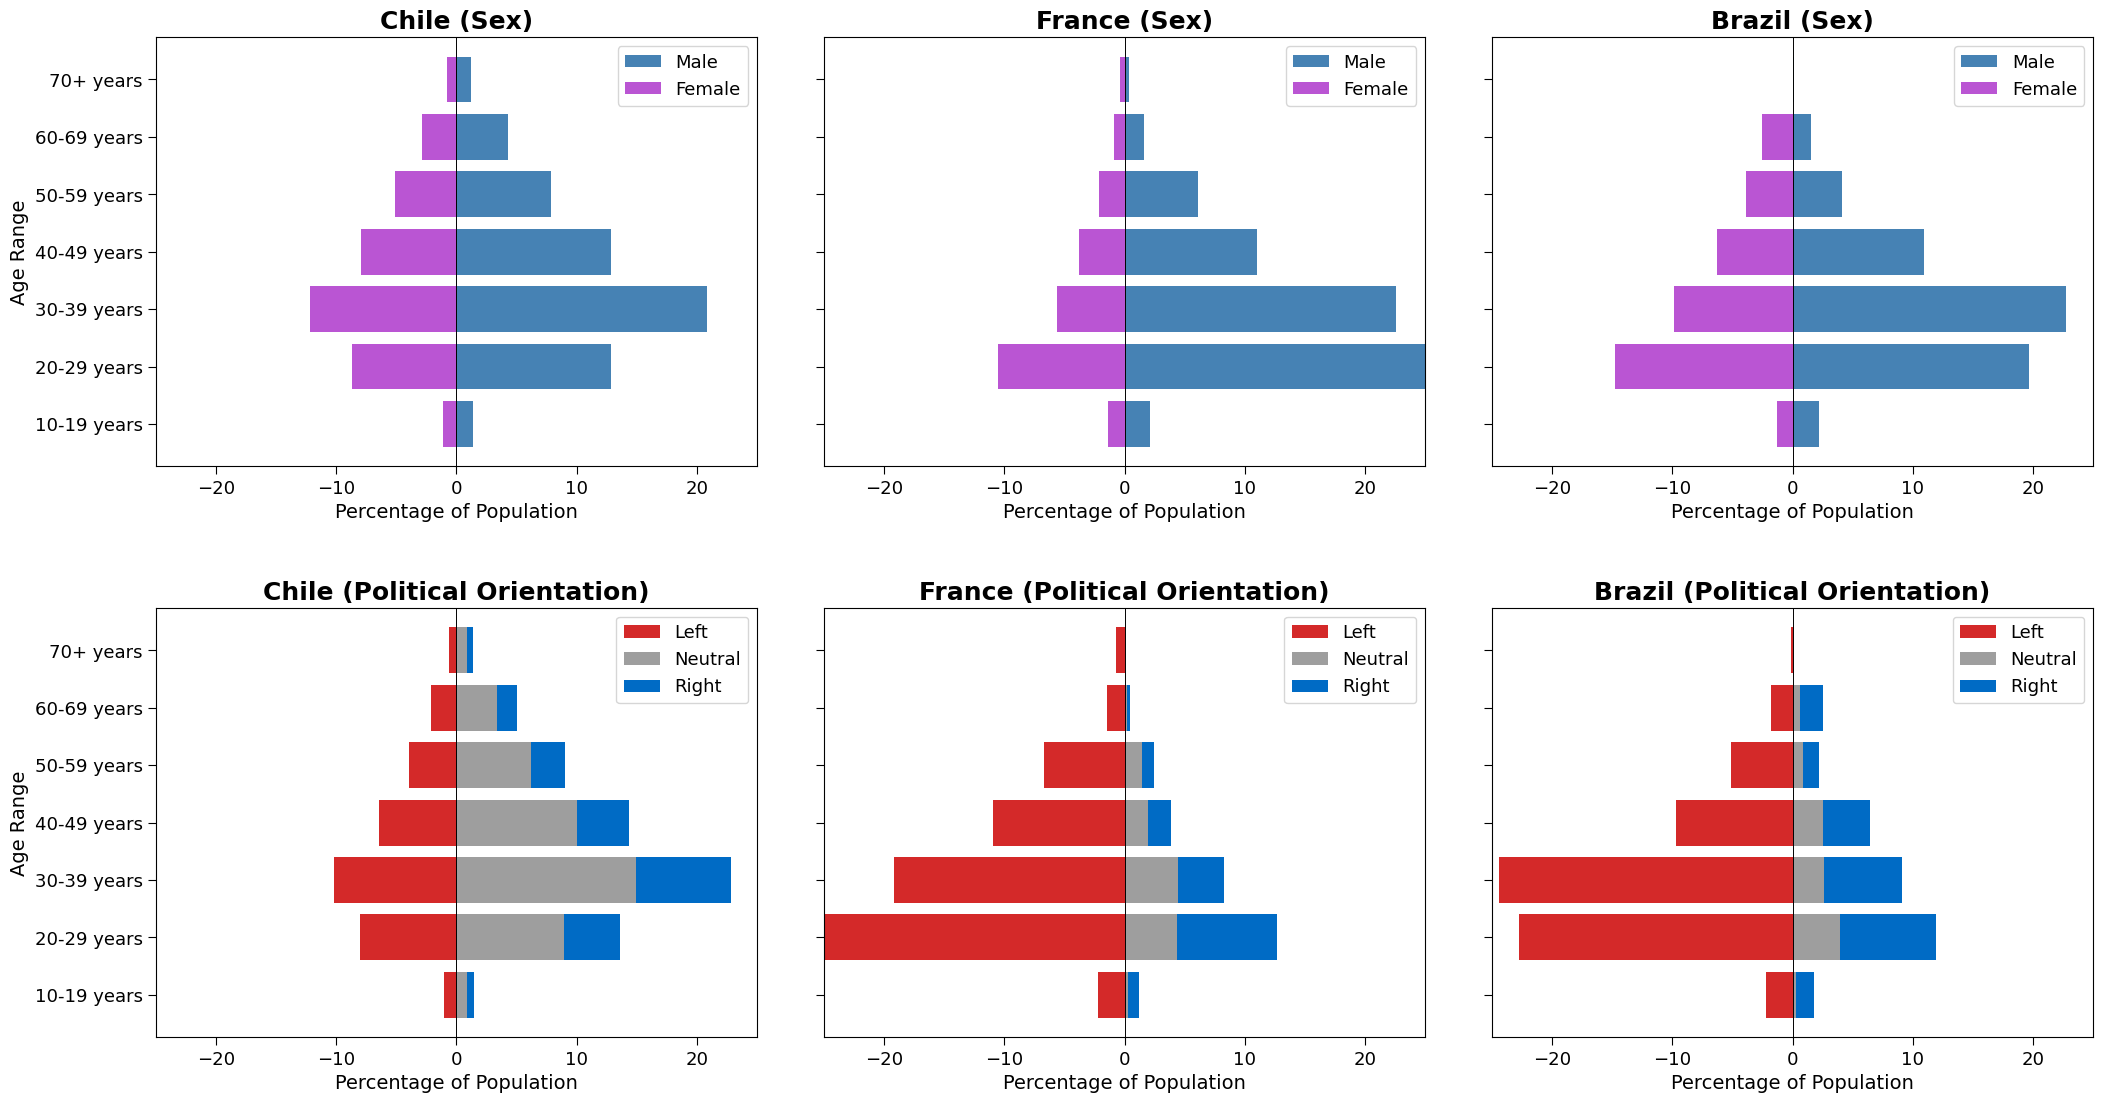

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# GLOBAL FONT CONFIG (Overleaf-friendly)
# ---------------------------
plt.rcParams.update({
    "font.size": 14,          # Base font size
    "axes.titlesize": 18,     # Title size
    "axes.labelsize": 16,     # Axis label size
    "xtick.labelsize": 13,    # Ticks
    "ytick.labelsize": 13,
    "legend.fontsize": 13,    # Legend
})

# ---------------------------
# (your same preparation functions)
# ---------------------------

def prepare_population_pyramid(df, age_exclude):
    df_filtered = df[
        (df["sex"].isin(["Male", "Female"])) &
        (~df["Age Range"].isin(age_exclude))
    ].copy()

    grouped = df_filtered.groupby(["Age Range", "sex"]).size().unstack(fill_value=0)
    total_individuals = grouped.sum().sum()
    grouped_percent = grouped / total_individuals * 100
    grouped_percent["Female"] *= -1

    age_order = [
        "10-19 years", "20-29 years", "30-39 years", "40-49 years",
        "50-59 years", "60-69 years", "70+ years"
    ]
    grouped_percent = grouped_percent.reindex(age_order)
    return grouped_percent


def prepare_political_orientation(df, age_exclude, orientation_exclude):
    df_filtered = df[
        (~df["Age Range"].isin(age_exclude)) &
        (~df["political_orientation"].isin(orientation_exclude))
    ].copy()

    grouped = df_filtered.groupby(["Age Range", "political_orientation"]).size().unstack(fill_value=0)
    total_individuals = grouped.sum().sum()
    grouped_percent = grouped / total_individuals * 100
    grouped_percent = grouped_percent.reindex([
        "10-19 years", "20-29 years", "30-39 years", "40-49 years",
        "50-59 years", "60-69 years", "70+ years"
    ])
    return grouped_percent

# Prepare datasets
grouped_chile_sex = prepare_population_pyramid(df_chile, ["Under 10"])
grouped_france_sex = prepare_population_pyramid(df_france, ["Other", "Skip"])
grouped_brazil_sex = prepare_population_pyramid(df_brazil, ["Other", "Skip"])

grouped_chile_pol = prepare_political_orientation(df_chile, ["Under 10"], ["Excluded"])
grouped_france_pol = prepare_political_orientation(df_france, ["Other", "Skip"], ["Excluded"])
grouped_brazil_pol = prepare_political_orientation(df_brazil, ["Other", "Skip"], ["Excluded"])

# Colors
sex_colors = {"Male": "#4682B4", "Female": "#BA55D3"}
pol_colors = {"Liberal": "#D42929", "Neutral": "#9E9E9E", "Conservative": "#006BC5"}

# ---------------------------
# FIGURE WITH IMPROVED FONTS
# ---------------------------
fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharey=True)

# First row: Sex
sex_datasets = {
    "Chile": grouped_chile_sex,
    "France": grouped_france_sex,
    "Brazil": grouped_brazil_sex
}

for ax, (country, data) in zip(axes[0], sex_datasets.items()):
    ax.barh(data.index, data["Male"], color=sex_colors["Male"], label="Male")
    ax.barh(data.index, data["Female"], color=sex_colors["Female"], label="Female")

    ax.set_title(f"{country} (Sex)", fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_xlim([-25, 25])

    ax.set_xlabel("Percentage of Population")

    if ax == axes[0, 0]:
        ax.set_ylabel("Age Range")

    ax.tick_params(axis='both', which='major', length=6)
    ax.legend()

# Second row: Ideology
pol_datasets = {
    "Chile": grouped_chile_pol,
    "France": grouped_france_pol,
    "Brazil": grouped_brazil_pol
}

for ax, (country, data) in zip(axes[1], pol_datasets.items()):
    for col in ["Liberal", "Neutral", "Conservative"]:
        if col not in data.columns:
            data[col] = 0

    liberal_vals = -data["Liberal"].abs()
    neutral_vals = data["Neutral"].abs()
    conservative_vals = data["Conservative"].abs()

    ax.barh(data.index, liberal_vals, color=pol_colors["Liberal"], label="Left")
    ax.barh(data.index, neutral_vals, left=np.zeros(len(data)),
            color=pol_colors["Neutral"], label="Neutral")
    ax.barh(data.index, conservative_vals, left=neutral_vals,
            color=pol_colors["Conservative"], label="Right")

    ax.set_title(f"{country} (Political Orientation)", fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_xlim([-25, 25])

    ax.set_xlabel("Percentage of Population")

    if ax == axes[1, 0]:
        ax.set_ylabel("Age Range")

    ax.tick_params(axis='both', which='major', length=6)
    ax.legend()

plt.tight_layout(pad=3.0)
plt.savefig("Output/Fig1.svg", format='svg', bbox_inches='tight')
plt.show()
